In [1]:
# Exploratory Data Analysis (EDA) on Medulloblastoma Cohort
# Data Source: cBioPortal (DKFZ, Nature 2017)
#
# References:
# 1. Dataset Paper: Northcott, P.A. et al. "The whole-genome landscape of medulloblastoma." Nature 547, 311–317 (2017).
# 2. Portal Citation: Cerami et al. Cancer Discov. (2012) & Gao et al. Sci. Signal. (2013)
#
# License: MIT License

In [2]:
# Hello everyone this study comes from the dataset of: https://www.cbioportal.org/study/summary?id=mbl_dkfz_2017

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the original clinical dataset
data = pd.read_csv('/content/mbl_dkfz_2017_clinical_data.tsv', sep ='\t')

print("this is the shape of the dataset before the cleaning:", data.shape)

# Drop rows missing fundamental clinical annotations immediately
df_clean = data.dropna(subset=['Age', 'Medulloblastoma Subgroup']).copy()

print("This is the new shape after the dataset cleaning:", df_clean.shape)

this is the shape of the dataset before the cleaning: (491, 18)
This is the new shape after the dataset cleaning: (476, 18)


In [4]:
data.head(10)

,Study ID,Patient ID,Sample ID,Age,Cancer Type,Cancer Type Detailed,Coverage Control,Tumor Sample Coverage(fold),Guessed Ploidy,Mutation Count,Sequencing Platform,OncoTree Code,Number of Samples Per Patient,Sex,Somatic Status,Sample Source Center,Medulloblastoma Subgroup,TMB (nonsynonymous)
0,mbl_dkfz_2017,ICGC_LFS_MB1,ICGC_LFS_MB1,11.0,Embryonal Tumor,Medulloblastoma,31.49,31.01,4.0,1.0,WGS,MBL,1,Female,Matched,ICGC,SHH,0.033333
1,mbl_dkfz_2017,ICGC_LFS_MB2,ICGC_LFS_MB2,14.0,Embryonal Tumor,Medulloblastoma,36.43,34.53,4.0,8.0,WGS,MBL,1,Male,Matched,ICGC,SHH,0.266667
2,mbl_dkfz_2017,ICGC_MB1,ICGC_MB1,6.0,Embryonal Tumor,Medulloblastoma,46.09,37.06,4.0,1.0,WGS,MBL,1,Female,Matched,ICGC,SHH,0.033333
3,mbl_dkfz_2017,ICGC_MB101,ICGC_MB101,39.0,Embryonal Tumor,Medulloblastoma,45.22,31.45,2.0,8.0,WGS,MBL,1,Female,Matched,ICGC,SHH,0.233333
4,mbl_dkfz_2017,ICGC_MB102,ICGC_MB102,23.0,Embryonal Tumor,Medulloblastoma,39.68,33.01,2.0,9.0,WGS,MBL,1,NaN,Matched,ICGC,SHH,0.266667
5,mbl_dkfz_2017,ICGC_MB104,ICGC_MB104,35.0,Embryonal Tumor,Medulloblastoma,32.68,33.27,4.0,6.0,WGS,MBL,1,Male,Matched,ICGC,SHH,0.200000
6,mbl_dkfz_2017,ICGC_MB106,ICGC_MB106,3.0,Embryonal Tumor,Medulloblastoma,41.23,46.03,4.0,2.0,WGS,MBL,1,Male,Matched,ICGC,Group 3,0.066667
7,mbl_dkfz_2017,ICGC_MB107,ICGC_MB107,15.0,Embryonal Tumor,Medulloblastoma,31.79,41.26,2.0,6.0,WGS,MBL,1,Male,Matched,ICGC,WNT,0.200000
8,mbl_dkfz_2017,ICGC_MB108,ICGC_MB108,10.0,Embryonal Tumor,Medulloblastoma,41.68,45.01,4.0,1.0,WGS,MBL,1,Male,Matched,ICGC,Group 4,0.033333
9,mbl_dkfz_2017,ICGC_MB110,ICGC_MB110,10.0,Embryonal Tumor,Medulloblastoma,44.01,43.74,4.0,7.0,WGS,MBL,1,Female,Matched,ICGC,Group 4,0.233333


In [5]:
# BIOINFORMATICS PIPELINE: Enforce numeric conversion on critical columns.
# Many samples contain the string "NA" as text, which breaks statistical grouping.
# By using errors='coerce', we transform invalid "NA" strings into true NaN values.
df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')
df_clean['Guessed Ploidy'] = pd.to_numeric(df_clean['Guessed Ploidy'], errors='coerce')
df_clean['Mutation Count'] = pd.to_numeric(df_clean['Mutation Count'], errors='coerce')
df_clean['Tumor Sample Coverage(fold)'] = pd.to_numeric(df_clean['Tumor Sample Coverage(fold)'], errors='coerce')

# Convert Ploidy to string so Seaborn treats it as a discrete categorical factor instead of a continuous scale
# We drop NaNs first, convert to int to remove decimals (e.g., 2.0 -> 2), then to string
df_clean['Estimated Ploidy'] = df_clean['Guessed Ploidy'].dropna().astype(int).astype(str)

print("Dataset shape after cleaning and type casting:", df_clean.shape)

Dataset shape after cleaning and type casting: (476, 19)


In [6]:
print(df_clean["Cancer Type"].unique())

# Due to the facr that we don't have other cancer type expect for 'embrional tumor' i prefer to do not select the column "Cancer Type" in the variable Key_columns

Key_columns = [
    "Age",
    "Guessed Ploidy",
    "Mutation Count",
    "Sex",
    "Medulloblastoma Subgroup",
    "TMB (nonsynonymous)"
]

['Embryonal Tumor']


In [7]:
demographic_distribution = df_clean.groupby(["Sex", "Medulloblastoma Subgroup"])["Age"].agg(["mean", "std", "count"])

print(f'Among the 476 cases we have:\n\n {demographic_distribution}')

print('\n' + "="*50 + "\n") #this code line is used only to create a softer view and has no real function in the code
mutations_distribution = df_clean.groupby(["Sex","Medulloblastoma Subgroup", "Guessed Ploidy"])[["TMB (nonsynonymous)", "Mutation Count"]].agg(["mean", "std", "count"])

print(f'In each medulloblastoma subgroup we have: {mutations_distribution}')

Among the 476 cases we have:

                                       mean        std  count
Sex    Medulloblastoma Subgroup                             
Female Group 3                    6.456829   3.157666     41
       Group 4                    9.277547   4.909997     53
       SHH                       14.593103  13.927326     58
       WNT                       11.070000   5.616058     20
Male   Group 3                    6.051059   3.966940     85
       Group 4                    9.456324   5.556249    136
       SHH                       13.152206  12.162133     68
       WNT                       16.230769  11.268199     13


In each medulloblastoma subgroup we have:                                                TMB (nonsynonymous)            \
                                                              mean       std   
Sex    Medulloblastoma Subgroup Guessed Ploidy                                 
Female Group 3                  2.0                       0.090476  0.07891

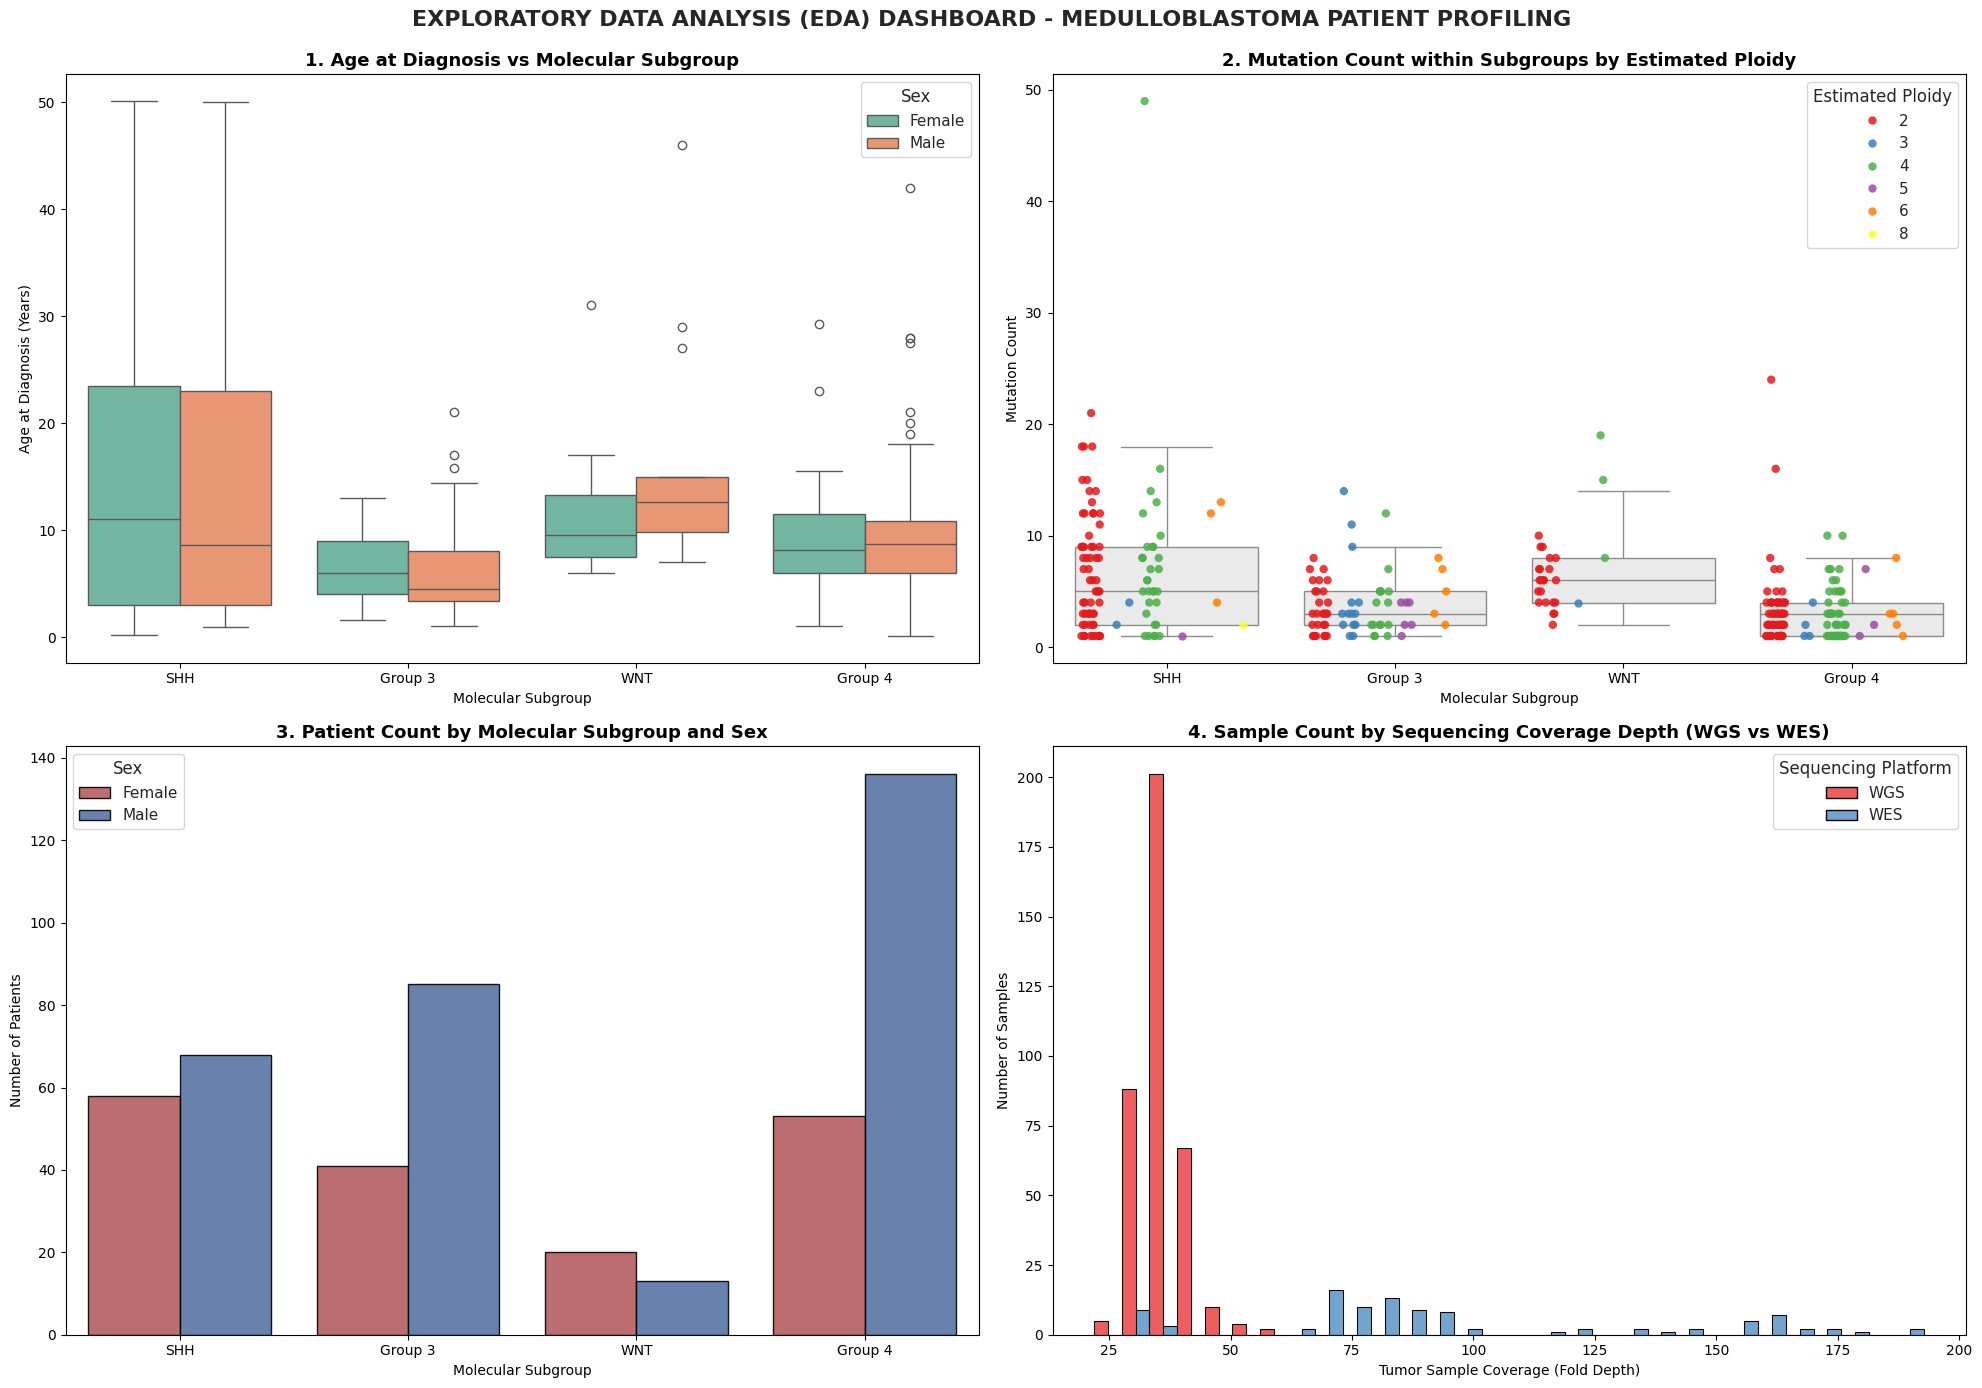

In [8]:
# =====================================================================
# PLOT CONFIGURATION (2x2 Dashboard Layout)
# =====================================================================
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 14))
# Fixed the warning: using standard set_theme
sns.set_theme(style="whitegrid") # Clean theme to support medical data visualization

# ---------------------------------------------------------------------
# PLOT 1 (Top-Left): Age Distribution across Molecular Subgroups
# BIOLOGICAL QUESTION: Are there specific molecular subgroups that predominantly
# affect infants/young children compared to adolescents or adults?
# ---------------------------------------------------------------------
sns.boxplot(
    data=df_clean,
    x="Medulloblastoma Subgroup",
    y="Age",
    hue="Sex",
    palette="Set2",
    ax=axes[0, 0]
)
axes[0, 0].set_title("1. Age at Diagnosis vs Molecular Subgroup", fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel("Molecular Subgroup")
axes[0, 0].set_ylabel("Age at Diagnosis (Years)")
# BIOLOGICAL INSIGHT:
# The SHH subgroup shows a prominent bimodal distribution, presenting in both infants and adults.
# In contrast, Group 3 and Group 4 tumors are strictly restricted to pediatric age ranges.

# ---------------------------------------------------------------------
# PLOT 2 (Top-Right): Tumor Mutational Burden (TMB) and Ploidy Instability
# BIOLOGICAL QUESTION: Does the mutation count vary based on estimated tumor ploidy?
# Do tumors with chromosomal aneuploidies (e.g., ploidy 4, 5, 6) accumulate more mutations?
# ---------------------------------------------------------------------
# Neutral background boxplot to show the general distribution without showing duplicates (fliers)
sns.boxplot(
    data=df_clean.dropna(subset=['Mutation Count']),
    x="Medulloblastoma Subgroup",
    y="Mutation Count",
    color="#EAEAEA", # Neutral grey background to emphasize ploidy dots
    showfliers=False,
    ax=axes[0, 1]
)
# Overlay distinct categorical points using the 'Set1' palette for clear ploidy segregation
sns.stripplot(
    data=df_clean.dropna(subset=['Mutation Count', 'Estimated Ploidy']).sort_values('Estimated Ploidy'),
    x="Medulloblastoma Subgroup",
    y="Mutation Count",
    hue="Estimated Ploidy",
    palette="Set1",
    jitter=0.25,
    size=6,
    alpha=0.85,
    dodge=True,
    ax=axes[0, 1]
)
axes[0, 1].set_title("2. Mutation Count within Subgroups by Estimated Ploidy", fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel("Molecular Subgroup")
axes[0, 1].set_ylabel("Mutation Count")
axes[0, 1].legend(title="Estimated Ploidy", loc="upper right")
# BIOLOGICAL INSIGHT:
# WNT and SHH subgroups display higher baseline mutation rates and standard deviations.
# An increase in structural ploidy (e.g., tetraploidy 4 or 6) does not dictate a linear automatic
# increase in point mutations, suggesting macro-genomic alterations act via distinct oncogenic paths.

# ---------------------------------------------------------------------
# PLOT 3 (Bottom-Left): Sex Disparity Analysis
# BIOLOGICAL QUESTION: Is there an underlying sex bias (Sex) within the
# four primary molecular variants of medulloblastoma?
# ---------------------------------------------------------------------
df_sex_filtered = df_clean[df_clean['Sex'].isin(['Male', 'Female'])]
sns.countplot(
    data=df_sex_filtered,
    x="Medulloblastoma Subgroup",
    hue="Sex",
    palette={"Male": "#4C72B0", "Female": "#C44E52"}, # Academic standard colors for gender
    edgecolor="black",
    alpha=0.9,
    ax=axes[1, 0]
)
axes[1, 0].set_title("3. Patient Count by Molecular Subgroup and Sex", fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel("Molecular Subgroup")
axes[1, 0].set_ylabel("Number of Patients")
# BIOLOGICAL INSIGHT:
# A striking and significant male predominance is observed within Group 3 and Group 4 cohorts.
# This marked gender imbalance perfectly mirrors widely validated epidemiology trends in embryonal tumors.

# ---------------------------------------------------------------------
# PLOT 4 (Bottom-Right): Sequencing Platform Benchmarking
# TECHNICAL QUESTION: Is there a systematic difference in tumor sequencing fold-coverage
# between Whole Genome Sequencing (WGS) and Whole Exome Sequencing (WES)?
# ---------------------------------------------------------------------
sns.histplot(
    data=df_clean.dropna(subset=['Tumor Sample Coverage(fold)']),
    x="Tumor Sample Coverage(fold)",
    hue="Sequencing Platform",
    multiple="dodge",
    bins=30,
    palette="Set1",
    edgecolor="black",
    alpha=0.7,
    ax=axes[1, 1]
)
axes[1, 1].set_title("4. Sample Count by Sequencing Coverage Depth (WGS vs WES)", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("Tumor Sample Coverage (Fold Depth)")
axes[1, 1].set_ylabel("Number of Samples")
# TECHNICAL INSIGHT:
# The histogram effectively validates the sequencing assays: WGS yields a tight, high-quality window
# around 30x-50x coverage, whereas WES targets the exome deeply, pushing distributions beyond 150x depth.

# =====================================================================
# 3. GLOBAL TITLE AND DASHBOARD RENDERING
# =====================================================================
plt.suptitle("EXPLORATORY DATA ANALYSIS (EDA) DASHBOARD - MEDULLOBLASTOMA PATIENT PROFILING", fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()
